---

[![Abrir no Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ppestana-supervisor/PDI_python/blob/main/topico3/Topico3.ipynb)

> **Nota importante**
>
> Este notebook é carregado diretamente a partir do repositório oficial no GitHub e é apenas para **leitura**.  
> As alterações **não ficam guardadas**.
>
> Para guardar uma versão pessoal:
> - No Colab, ir a **Ficheiro → Guardar uma cópia no Drive**.  
> - A cópia ficará disponível em `O meu Drive / Colab Notebooks`.
>
> Para colaboração:
> - Abrir a versão pessoal no Google Drive.  
> - Clicar em **Partilhar** → **Qualquer pessoa com o link pode editar** (ou adicionar os colegas manualmente).  
> - A partir daí, todos podem editar em tempo real, como num Google Docs.
>
> Para guardar resultados (imagens, ficheiros, etc.) no  Drive:
> ```python
> from google.colab import drive
> drive.mount('/content/drive')
> ```
> Depois gravar, por exemplo, em:
> ```python
> img.save('/content/drive/MyDrive/PDI_outputs/resultado.png')
> ```

---

In [ ]:
### !!! Executar esta célula primeiro, se dentro do Colab
# Quando dentro do Colab, clonar o repositório completo para garantir acesso à pasta de imagens
!git clone https://github.com/ppestana-supervisor/PDI_python.git
%cd PDI_python/topico5

# 14. Backpropagation Visualizado

Neste notebook damos o passo seguinte no caminho da compreensão das redes neuronais: visualizar o processo de **aprendizagem por backpropagation**.  
A partir de um conjunto de dados simples, construído a partir de pequenas imagens artificiais e de apenas duas características, acompanhamos o modelo durante o treino e observamos como os **pesos se ajustam** iterativamente para minimizar o erro.  
O objetivo é tornar visível o que normalmente acontece de forma opaca nas frameworks modernas: como a fronteira de decisão se desloca no espaço dos dados, como a superfície de perda orienta a direção do gradiente e como a taxa de aprendizagem influencia a estabilidade do processo.  
Através de visualizações sucessivas — fronteiras, superfícies e trajetórias — este capítulo revela a geometria interna do *backpropagation*.

## 14.1. Geração de dados e extração de características

Nesta célula criamos um pequeno conjunto de dados de treino a partir de imagens sintéticas.

### 1. Convolução simples

A função `conv2d_same()` implementa uma convolução 2D elementar, com *padding* automático para preservar o tamanho da imagem (`mode='same'`).  
É usada para calcular gradientes locais (por exemplo, operadores de Sobel).

### 2. Magnitude do gradiente (Sobel)

A função `sobel_magnitude()` aplica os dois filtros Sobel (horizontal e vertical) e combina as respostas:  
\[
\text{magnitude} = \sqrt{G_x^2 + G_y^2}
\]
O valor médio desta magnitude servirá como indicador da **energia de arestas** da imagem — uma métrica simples de textura ou complexidade.

### 3. Criação de imagens sintéticas

A função `make_tiny_image()` gera pequenas imagens 16×16 compostas por:
- pontos aleatórios de brilho (simulando textura),  
- e uma faixa vertical ou horizontal (simulando um padrão estrutural).

O resultado é uma imagem binária simples mas visualmente diversa.

### 4. Extração de características

A função `extract_features()` devolve um vetor de duas dimensões:
- intensidade média (`mean_intensity`);  
- energia média das arestas (`edge_energy`).

Cada imagem é assim representada por um ponto em \(\mathbb{R}^2\).

### 5. Criação do conjunto de dados

Com `N = 300`, geramos 300 imagens e obtemos uma matriz `X` com dimensão `(300, 2)`.  
As etiquetas `y` são calculadas de forma sintética através de uma combinação linear das duas características:
\[
\text{logit} = 0.7 \cdot x_1 + 0.3 \cdot x_2 - 0.25 + \text{ruído}
\]
onde `y = 1` se `logit > 0`, caso contrário `y = 0`.

### Objetivo didático

Este processo cria um problema de **classificação linear bidimensional** inspirado em dados visuais,  
perfeito para observar graficamente a dinâmica do *backpropagation* —  
como o modelo ajusta os pesos \(w_1\), \(w_2\) e o *bias* \(b\) para alinhar a fronteira de decisão com os dados.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

def conv2d_same(img, kernel):
    kh, kw = kernel.shape
    pad_h, pad_w = kh // 2, kw // 2
    padded = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant')
    H, W = img.shape
    out = np.zeros_like(img, dtype=float)
    for i in range(H):
        for j in range(W):
            window = padded[i:i+kh, j:j+kw]
            out[i, j] = np.sum(window * kernel)
    return out

def sobel_magnitude(img):
    Kx = np.array([[1,0,-1],[2,0,-2],[1,0,-1]], dtype=float)
    Ky = np.array([[1,2,1],[0,0,0],[-1,-2,-1]], dtype=float)
    gx = conv2d_same(img, Kx)
    gy = conv2d_same(img, Ky)
    return np.sqrt(gx**2 + gy**2)

def make_tiny_image(size=16):
    # random blobs (simulate texture/edges) + random brightness
    img = np.zeros((size, size), dtype=float)
    # sprinkle a few bright dots
    for _ in range(np.random.randint(3, 8)):
        x = np.random.randint(0, size)
        y = np.random.randint(0, size)
        img[max(0,x-1):min(size,x+2), max(0,y-1):min(size,y+2)] += np.random.uniform(0.3, 1.0)
    img = np.clip(img, 0, 1)
    # add a vertical or horizontal stripe sometimes
    if np.random.rand() < 0.5:
        c = np.random.randint(2, size-2)
        img[:, c-1:c+1] += np.random.uniform(0.2, 0.6)
    else:
        r = np.random.randint(2, size-2)
        img[r-1:r+1, :] += np.random.uniform(0.2, 0.6)
    return np.clip(img, 0, 1)

def extract_features(img):
    mean_intensity = img.mean()
    edge_energy = sobel_magnitude(img).mean()
    return np.array([mean_intensity, edge_energy], dtype=float)

N = 300
imgs = [make_tiny_image(16) for _ in range(N)]
X = np.stack([extract_features(im) for im in imgs], axis=0)

w_true = np.array([0.7, 0.3])
b_true = -0.25
logit = X @ w_true + b_true + 0.05*np.random.randn(N)
y = (logit > 0).astype(float)

print("X shape:", X.shape, " y shape:", y.shape)

X shape: (300, 2)  y shape: (300,)


## 14.2. Visualização do conjunto de dados

Antes de iniciarmos qualquer treino, é fundamental observar o aspeto dos dados — tanto no domínio da imagem como no das características.

### 1. Amostras visuais

O primeiro bloco (`fig, axs = plt.subplots(...)`) apresenta cinco imagens sintéticas do conjunto gerado.  
Cada uma contém uma combinação aleatória de:
- pequenas manchas luminosas (textura de fundo);  
- e uma faixa vertical ou horizontal (estrutura dominante).

Apesar de simples, estas imagens produzem valores diferentes de intensidade média e energia de arestas — os dois atributos que iremos usar para a classificação.

### 2. Espaço de características

O segundo gráfico representa cada imagem como um ponto no plano \((x_1, x_2)\), onde:
- \(x_1\) = intensidade média dos píxeis;  
- \(x_2\) = energia média do gradiente (Sobel).

As cores indicam a classe sintética (`y ∈ {0,1}`) atribuída a cada imagem.  
A fronteira entre as cores já sugere uma **separação aproximadamente linear**, o que confirma que o problema pode ser resolvido com um classificador linear simples.

### Nota didática

Esta representação é especialmente útil porque permite **visualizar o processo de aprendizagem** nas próximas células:
- A fronteira de decisão será uma linha neste mesmo plano;  
- Durante o *backpropagation*, essa linha irá mover-se e rodar até alinhar-se com a divisão natural entre as classes.  
Deste modo, todo o processo de ajuste de pesos pode ser acompanhado visualmente.

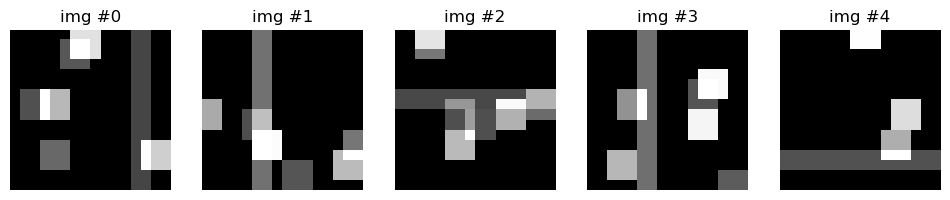

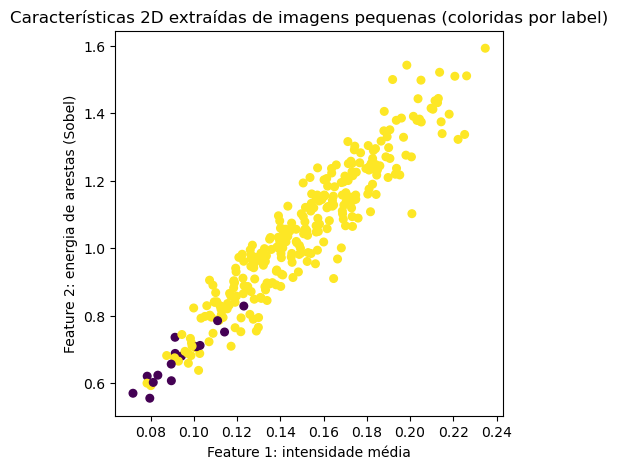

In [9]:
fig, axs = plt.subplots(1, 5, figsize=(12, 2.5))
for i in range(5):
    axs[i].imshow(imgs[i], cmap="gray")
    axs[i].set_title(f"img #{i}")
    axs[i].axis("off")
plt.show()

plt.figure(figsize=(5,5))
plt.scatter(X[:,0], X[:,1], c=y, s=30)
plt.xlabel("Feature 1: intensidade média")
plt.ylabel("Feature 2: energia de arestas (Sobel)")
plt.title("Características 2D extraídas de imagens pequenas (coloridas por label)")
plt.show()

## 14.3. Implementação do treino e do *backpropagation* manual

Chegámos ao ponto central deste notebook: observar como o modelo ajusta os pesos e o *bias* de forma automática, através da descida do gradiente (*gradient descent*).  
Todo o processo é aqui implementado explicitamente, sem recurso a frameworks de *deep learning*.

### 1. Modelo e funções auxiliares

- **`sigmoid(z)`**  
  Função de ativação logística:
$$
  \sigma(z) = \frac{1}{1 + e^{-z}}
$$
  Converte valores contínuos em probabilidades no intervalo (0, 1).  
  A sua derivada simples facilita o cálculo dos gradientes.

- **`forward(X, params)`**  
  Calcula a predição do modelo linear:
$$
  z = X \cdot w + b, \quad \hat{y} = \sigma(z)
$$
  onde $ w \in \mathbb{R}^2\ $ e $ b \in \mathbb{R}\ $.

- **`mse_loss(y_hat, y)`**  
  Mede o erro médio quadrático (MSE) entre as predições e as etiquetas reais:
$$
  L = \frac{1}{N} \sum_i (\hat{y}_i - y_i)^2
$$
  Apesar de a função logística normalmente usar a perda binária cruzada, aqui opta-se pelo MSE por ser mais intuitiva e fácil de derivar analiticamente.

### 2. Cálculo dos gradientes

A função `compute_grads()` implementa o *backpropagation* de forma explícita, passo a passo:

1. Derivada da perda em relação à predição:
$$
   \frac{\partial L}{\partial \hat{y}} = \frac{2(\hat{y} - y)}{N}
$$
2. Derivada da sigmóide:
$$
   \frac{\partial \hat{y}}{\partial z} = \hat{y}(1 - \hat{y})
$$
3. Derivada da perda em relação a \(z\):
$$
   \frac{\partial L}{\partial z} = \frac{\partial L}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z}
$$
4. Derivadas em relação aos parâmetros:
$$
   \frac{\partial L}{\partial w} = X^T \cdot \frac{\partial L}{\partial z}, \quad
   \frac{\partial L}{\partial b} = \sum_i \frac{\partial L}{\partial z_i}
$$

### 3. Ciclo de treino

Durante 200 épocas:
- Calcula-se a predição (`forward`);  
- Avalia-se a perda (`mse_loss`);  
- Obtêm-se os gradientes (`compute_grads`);  
- Atualizam-se os parâmetros pela regra da **descida do gradiente**:
$$
  w \leftarrow w - \eta \frac{\partial L}{\partial w}, \quad
  b \leftarrow b - \eta \frac{\partial L}{\partial b}
$$
  onde $\eta = 0.3\$ é a taxa de aprendizagem.

O vetor `loss_history` guarda a evolução do erro ao longo das épocas.

### 4. Visualização da perda

O gráfico final mostra a **curva de convergência da perda (MSE)** —  
deve decrescer gradualmente até estabilizar, confirmando que o modelo está a ajustar-se aos dados.

### Observação didática

Esta implementação torna visível a lógica interna do *backpropagation*:
- cada gradiente é derivado manualmente e aplicado diretamente,  
- a trajetória dos parâmetros (`w_path`, `b_path`) pode ser visualizada para mostrar como o plano de decisão se desloca no espaço das características.

Nos próximos passos, iremos precisamente representar essa trajetória —  
mostrando, no plano 2D das *features*, como a fronteira de decisão evolui ao longo do treino.

Parâmetros finais: w = [0.77694949 1.35758416]  b = 1.0087282979678072
Perda final: 0.04442553334130998


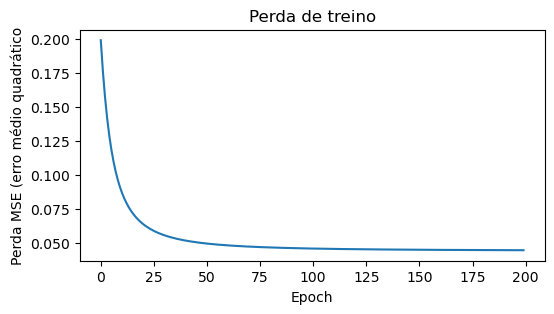

In [10]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def forward(X, params):
    w, b = params["w"], params["b"]
    z = X @ w + b  # shape (N,)
    y_hat = sigmoid(z)
    return y_hat, z

def mse_loss(y_hat, y):
    return np.mean((y_hat - y)**2)

def compute_grads(X, y, y_hat, z):
    # dL/dy_hat = 2*(y_hat - y)/N
    N = X.shape[0]
    dL_dyhat = 2.0 * (y_hat - y) / N
    # dy_hat/dz = sigmoid'(z) = y_hat*(1-y_hat)
    dyhat_dz = y_hat * (1.0 - y_hat)
    dL_dz = dL_dyhat * dyhat_dz  # shape (N,)
    # dz/dw = X, dz/db = 1
    grad_w = X.T @ dL_dz                 # shape (2,)
    grad_b = np.sum(dL_dz)               # scalar
    return grad_w, grad_b

params = {
    "w": np.random.randn(2) * 0.5,
    "b": 0.0
}

lr = 0.3
epochs = 200

loss_history = []
w_path = [params["w"].copy()]
b_path = [params["b"]]

for ep in range(epochs):
    y_hat, z = forward(X, params)
    loss = mse_loss(y_hat, y)
    loss_history.append(loss)

    grad_w, grad_b = compute_grads(X, y, y_hat, z)
    # Update (gradient descent)
    params["w"] -= lr * grad_w
    params["b"] -= lr * grad_b

    w_path.append(params["w"].copy())
    b_path.append(params["b"])

print("Parâmetros finais: w =", params["w"], " b =", params["b"])
print("Perda final:", loss_history[-1])

plt.figure(figsize=(6,3))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Perda MSE (erro médio quadrático)")
plt.title("Perda de treino")
plt.show()

## 14.4. Visualização da evolução da fronteira de decisão

Para compreender intuitivamente o que acontece durante o *backpropagation*, é útil observar como os **pesos aprendidos** alteram a **fronteira de decisão** do modelo no plano das características.

### 1. Representação dos dados
O gráfico mostra novamente os pontos do conjunto de treino:
- cada ponto representa uma imagem (duas *features*);  
- a cor indica a classe real (`y ∈ {0,1}`).

### 2. Cálculo da fronteira de decisão
A fronteira linear é dada pela equação:
$$
w_0\,x_1 + w_1\,x_2 + b = 0
$$
que se pode reescrever como:
$$
x_2 = -\frac{w_0}{w_1}x_1 - \frac{b}{w_1}
$$
Esta linha separa as regiões do plano onde a saída da sigmóide é superior ou inferior a 0.5.

Em cada iteração, a descida do gradiente ajusta $ w_0\ $, $ w_1\ $ e $ b $, deslocando e rodando esta linha para reduzir o erro de classificação.

### 3. Visualização temporal
A função `plot_decision_boundaries()` desenha várias linhas correspondentes a diferentes épocas (1, 5, 20, 50, 100, 200).  
Cada linha mostra a posição da fronteira após esse número de atualizações dos parâmetros.

- **Épocas iniciais:** a fronteira é quase aleatória.  
- **Épocas intermédias:** começa a alinhar-se com a separação natural dos dados.  
- **Épocas finais:** estabiliza numa posição que minimiza o erro (ou próxima disso).

### 4. Interpretação didática
Esta figura permite “ver” o *backpropagation* em ação:  
o gradiente não é um conceito abstrato — ele **move literalmente a fronteira de decisão**.  
Com poucas iterações, o modelo ajusta-se progressivamente até aprender uma regra simples que separa as duas classes.

O exercício sintetiza todo o capítulo:
- a convolução e extração de características forneceram os dados de entrada;  
- o *forward pass* produziu predições;  
- o *backpropagation* ajustou os parâmetros;  
- e agora vemos o resultado geométrico desse processo de aprendizagem.

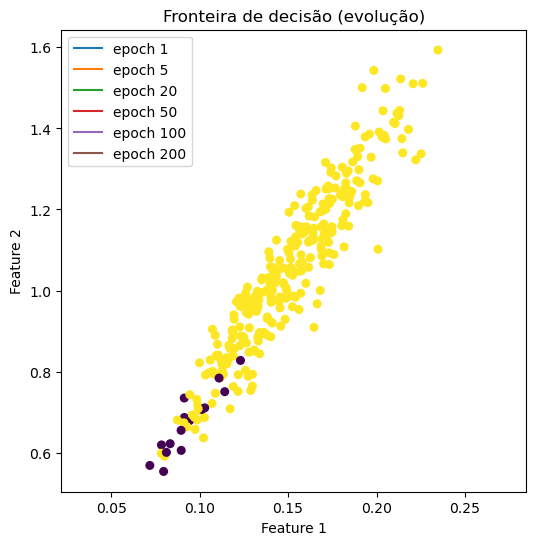

In [11]:
def plot_decision_boundaries(X, y, w_path, b_path, steps=(1, 5, 20, 200)):
    plt.figure(figsize=(6,6))
    plt.scatter(X[:,0], X[:,1], c=y, s=30)
    xmin, xmax = X[:,0].min()-0.05, X[:,0].max()+0.05
    grid_x = np.linspace(xmin, xmax, 100)

    for step in steps:
        w = w_path[min(step, len(w_path)-1)]
        b = b_path[min(step, len(b_path)-1)]
        if abs(w[1]) < 1e-6:
            continue
        line_y = -(w[0]/w[1])*grid_x - b/w[1]
        plt.plot(grid_x, line_y, label=f"epoch {step}")

    plt.xlim(xmin, xmax)
    ymin, ymax = X[:,1].min()-0.05, X[:,1].max()+0.05
    plt.ylim(ymin, ymax)
    plt.legend()
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title("Fronteira de decisão (evolução)")
    plt.show()

plot_decision_boundaries(X, y, w_path, b_path, steps=(1, 5, 20, 50, 100, 200))

## 14.5. Superfície da função de perda e trajetória dos pesos

Depois de observar a evolução da fronteira de decisão no plano das *features*, passamos agora a uma perspetiva complementar:  
visualizar o processo de aprendizagem no **espaço dos parâmetros** \( (w_1, w_2) \).

### 1. Função de perda no espaço dos pesos

A função `dataset_loss_w()` calcula a perda média quadrática (MSE) para valores arbitrários de \(w = [w_1, w_2]\) e um *bias* \(b\) fixo.  
Assim, conseguimos avaliar o valor da função de perda para cada ponto da grelha de pesos, mantendo o *bias* constante.

A figura obtida representa a **superfície da função de custo**:
$$
L(w_1, w_2) = \frac{1}{N} \sum_i (\hat{y}_i - y_i)^2
$$
onde $ \hat{y}_i = \sigma(X_i \cdot w + b)\ $.

### 2. Interpretação visual

O gráfico de contornos (*contour plot*) mostra zonas de maior e menor perda:
- as **regiões escuras** correspondem a valores de perda elevados (má ajuste);  
- as **regiões claras** indicam combinações de pesos que produzem menor erro.

Sobre essa superfície é desenhada a **trajetória dos pesos** durante o treino:
- cada ponto representa o vetor \(w = (w_1, w_2)\) após algumas iterações da descida do gradiente;  
- as setas indicam a direção e o sentido de atualização dos parâmetros.

### 3. Leitura geométrica

Esta visualização torna explícita a dinâmica do *backpropagation*:
- o gradiente aponta sempre na direção de descida mais íngreme da superfície;  
- a taxa de aprendizagem (η) controla o tamanho dos passos;  
- o processo converge gradualmente para o mínimo local da função de custo.

O resultado é análogo a uma **partícula que “rola” pelo vale da função de perda**, movendo-se até atingir uma zona de estabilidade —  
a combinação de pesos que melhor separa as classes.

### 4. Valor didático

Esta representação mostra de forma direta o que raramente se observa quando se usa uma framework de *deep learning*:  
como os pesos evoluem realmente num espaço contínuo e como a superfície de erro orienta essa trajetória.  
É um complemento visual essencial à intuição do *backpropagation*.

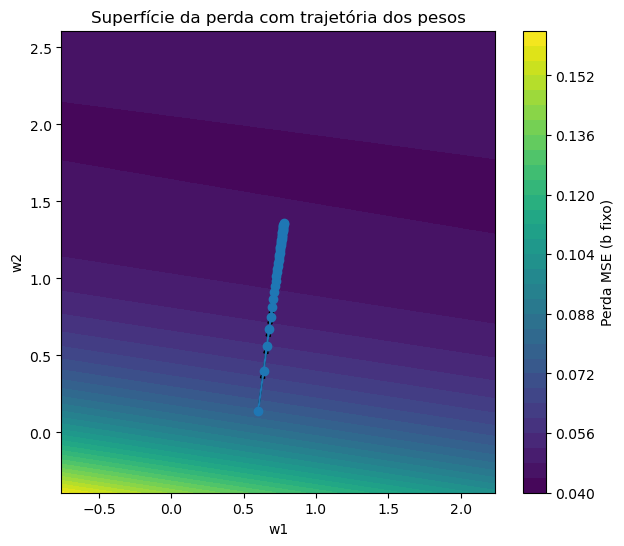

In [12]:
def dataset_loss_w(X, y, w, b):
    z = X @ w + b
    y_hat = 1.0 / (1.0 + np.exp(-z))
    return np.mean((y_hat - y)**2)

def plot_loss_surface_with_path(X, y, w_path, b_path, grid_extent=1.5, grid_res=100, step=3):
    w_arr = np.array(w_path)
    w_center = w_arr.mean(axis=0)
    w1_min, w1_max = w_center[0]-grid_extent, w_center[0]+grid_extent
    w2_min, w2_max = w_center[1]-grid_extent, w_center[1]+grid_extent

    w1_vals = np.linspace(w1_min, w1_max, grid_res)
    w2_vals = np.linspace(w2_min, w2_max, grid_res)
    W1, W2 = np.meshgrid(w1_vals, w2_vals)

    b_fix = b_path[-1] 
    L = np.zeros_like(W1)
    for i in range(grid_res):
        for j in range(grid_res):
            w = np.array([W1[i,j], W2[i,j]])
            L[i,j] = dataset_loss_w(X, y, w, b_fix)

    plt.figure(figsize=(7,6))
    cs = plt.contourf(W1, W2, L, levels=30)
    plt.colorbar(cs, label="Perda MSE (b fixo)")
    plt.xlabel("w1")
    plt.ylabel("w2")
    plt.title("Superfície da perda com trajetória dos pesos")

    path = np.array(w_path)[::step]
    plt.plot(path[:,0], path[:,1], marker='o')
    for i in range(len(path)-1):
        p, q = path[i], path[i+1]
        d = q - p
        plt.arrow(p[0], p[1], d[0], d[1], head_width=0.03, length_includes_head=True)

    plt.show()

plot_loss_surface_with_path(X, y, w_path, b_path, grid_extent=1.5, grid_res=80, step=5)

## 14.6. Efeito da taxa de aprendizagem (*learning rate*)

Nesta parte exploramos o impacto da **taxa de aprendizagem (η)** no comportamento do treino por descida do gradiente.  
A ideia é simples: se os passos do gradiente forem demasiado pequenos, o treino torna-se lento;  
se forem demasiado grandes, o modelo oscila e pode não convergir.

### 1. Função `train_with_lr()`

Esta função repete o treino do modelo logístico, mas permite ajustar o parâmetro `lr`.  
Para cada valor de taxa de aprendizagem:
- inicializa pesos e *bias* aleatoriamente;  
- executa a passagem direta (*forward pass*), calcula a perda (MSE) e os gradientes;  
- atualiza os parâmetros segundo a regra:
$$
  w \leftarrow w - \eta \, \nabla_w L, \quad b \leftarrow b - \eta \, \nabla_b L
$$
- guarda o histórico de pesos, *bias* e perdas para análise posterior.

### 2. Comparação de taxas

Foram testados dois valores:
- **η = 0.1** — passos curtos e estáveis;  
- **η = 0.6** — passos longos e potencialmente instáveis.

O gráfico da evolução da perda mostra:
- para η = 0.1, a descida é suave e progressiva, mas pode demorar a atingir o mínimo;  
- para η = 0.6, a perda diminui mais rapidamente no início, mas tende a oscilar à volta do mínimo.

Este comportamento reflete o equilíbrio fundamental entre **velocidade** e **estabilidade** no treino de redes neuronais.

### 3. Visualização no espaço dos pesos

A função `plot_two_paths_on_surface()` sobrepõe as duas trajetórias no espaço dos parâmetros $ (w_1, w_2)\$,  
sobre a mesma superfície de perda já visualizada anteriormente.

- Cada linha mostra o percurso que os pesos seguem durante o treino.  
- As cores indicam o valor da perda (mais escuro → maior erro).  
- Quando a taxa de aprendizagem é pequena, a trajetória é curta e converge de forma gradual.  
- Com uma taxa elevada, o percurso tende a saltar de um lado para o outro do vale, podendo ultrapassar o mínimo várias vezes.

### 4. Conclusão didática

Esta visualização demonstra, de forma geométrica, o papel crucial da taxa de aprendizagem:  
ela controla **a amplitude dos passos** ao longo da superfície de perda.  
Um valor adequado permite descer rapidamente em direção ao mínimo sem ultrapassá-lo,  
enquanto valores demasiado altos tornam o processo errático ou divergente.

Esta relação é um dos princípios fundamentais do treino de redes neuronais —  
e aqui é observada diretamente, no espaço real dos pesos.

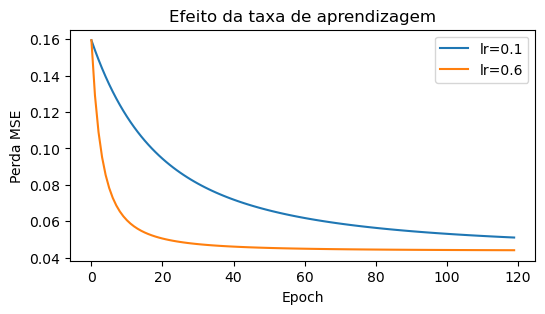

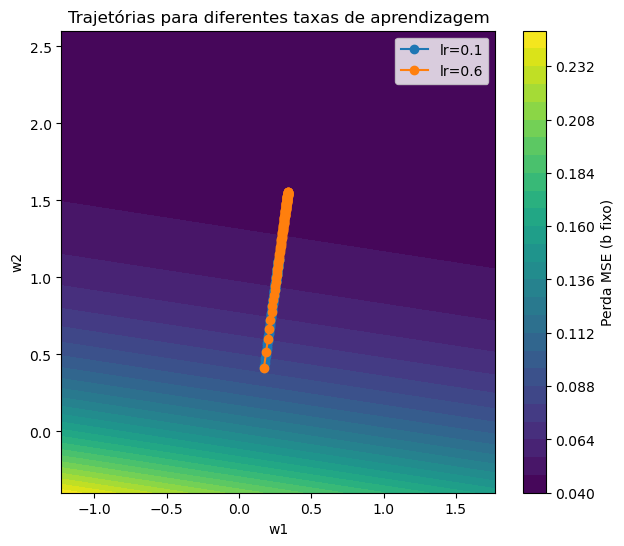

In [13]:
def train_with_lr(X, y, lr, epochs=120, seed=0):
    rng = np.random.default_rng(seed)
    params = {"w": rng.normal(0, 0.5, size=(2,)), "b": 0.0}
    loss_hist, w_hist, b_hist = [], [params["w"].copy()], [params["b"]]

    for _ in range(epochs):
        # forward
        z = X @ params["w"] + params["b"]
        y_hat = 1.0 / (1.0 + np.exp(-z))
        # loss
        loss = np.mean((y_hat - y)**2)
        loss_hist.append(loss)
        # grads
        N = X.shape[0]
        dL_dyhat = 2.0 * (y_hat - y) / N
        dL_dz = dL_dyhat * y_hat * (1.0 - y_hat)
        grad_w = X.T @ dL_dz
        grad_b = np.sum(dL_dz)
        # update
        params["w"] -= lr * grad_w
        params["b"] -= lr * grad_b
        w_hist.append(params["w"].copy())
        b_hist.append(params["b"])
    return np.array(w_hist), np.array(b_hist), np.array(loss_hist)

w_hist_small, b_hist_small, loss_small = train_with_lr(X, y, lr=0.1, epochs=120, seed=1)
w_hist_big,   b_hist_big,   loss_big   = train_with_lr(X, y, lr=0.6, epochs=120, seed=1)

plt.figure(figsize=(6,3))
plt.plot(loss_small, label="lr=0.1")
plt.plot(loss_big, label="lr=0.6")
plt.xlabel("Epoch"); plt.ylabel("Perda MSE"); plt.title("Efeito da taxa de aprendizagem")
plt.legend(); plt.show()

def plot_two_paths_on_surface(X, y, w_hist_a, w_hist_b, b_fix, labels=("lr=0.1","lr=0.6")):
    w_all = np.vstack([w_hist_a, w_hist_b])
    w_center = w_all.mean(axis=0)
    w1_min, w1_max = w_center[0]-1.5, w_center[0]+1.5
    w2_min, w2_max = w_center[1]-1.5, w_center[1]+1.5

    w1_vals = np.linspace(w1_min, w1_max, 100)
    w2_vals = np.linspace(w2_min, w2_max, 100)
    W1, W2 = np.meshgrid(w1_vals, w2_vals)
    L = np.zeros_like(W1)

    for i in range(W1.shape[0]):
        for j in range(W1.shape[1]):
            w = np.array([W1[i,j], W2[i,j]])
            z = X @ w + b_fix
            y_hat = 1.0 / (1.0 + np.exp(-z))
            L[i,j] = np.mean((y_hat - y)**2)

    plt.figure(figsize=(7,6))
    cs = plt.contourf(W1, W2, L, levels=30)
    plt.colorbar(cs, label="Perda MSE (b fixo)")
    plt.xlabel("w1"); plt.ylabel("w2")
    plt.title("Trajetórias para diferentes taxas de aprendizagem")

    # paths
    plt.plot(w_hist_a[:,0], w_hist_a[:,1], marker='o', label=labels[0])
    plt.plot(w_hist_b[:,0], w_hist_b[:,1], marker='o', label=labels[1])
    plt.legend()
    plt.show()

plot_two_paths_on_surface(X, y, w_hist_small, w_hist_big, b_fix=b_hist_small[-1])

## 14.7. [Future Work] — Visual Analytics do Backpropagation
*(Possível extensão neste notebook ou ponto de partida para projeto dos estudantes)*

Uma extensão natural deste notebook seria o desenvolvimento de uma **versão interativa do processo de aprendizagem** por descida de gradiente.  
O objetivo seria tornar o conceito de *backpropagation* **visualmente manipulável**, permitindo observar como os parâmetros se ajustam em tempo real quando o utilizador altera as condições de treino.

### Pipeline proposto

| Etapa | Ação | Resultado esperado |
|-------|------|--------------------|
| **1. Modelo base** | Reutilizar o perceptron simples com duas features e um bias. | Base experimental para observação direta do gradiente. |
| **2. Superfície de erro** | Calcular previamente a *loss surface* com `dataset_loss_w()`. | Mapa de contorno que representa a paisagem de otimização. |
| **3. Interatividade com `ipywidgets`** | Criar *sliders* para ajustar `learning rate`, número de épocas, e botões para *step* e *reset*. | Permite ao utilizador controlar o treino de forma incremental. |
| **4. Atualização dinâmica** | A cada iteração, redesenhar: <br>– o ponto atual na superfície de erro; <br>– a fronteira de decisão no espaço das features; <br>– o valor atual da perda. | Visualização simultânea do movimento do gradiente e da evolução da decisão. |
| **5. Histórico de trajetórias** | Armazenar as posições sucessivas dos pesos (`w₁`, `w₂`) e sobrepor as trajetórias. | Representa graficamente a convergência (ou oscilação) do algoritmo. |

### Extensões possíveis

- Comparar **diferentes *optimizers*** (SGD, Momentum, Adam) e visualizar as suas trajetórias distintas.  
- Mostrar separadamente os gradientes parciais (`∂L/∂w₁`, `∂L/∂w₂`) e como influenciam a direção de atualização.  
- Adicionar uma visualização tridimensional interativa da superfície com `plotly` ou `matplotlib.widgets`.

### Valor didático

Esta extensão transformaria o notebook num **laboratório visual de aprendizagem automática**,  
em que o estudante vê literalmente o modelo “aprender” sobre a paisagem de erro.  
O conceito abstrato de *backpropagation* torna-se observável e explorável, permitindo uma compreensão intuitiva do papel dos gradientes, da taxa de aprendizagem e da estabilidade da convergência.

## 14.8. Conclusão

Com este notebook encerramos a construção manual de uma rede neuronal completa:  
da geração de dados, à passagem direta (*forward pass*), cálculo explícito dos gradientes, descida do gradiente e visualização da convergência.

Observámos:
- como a **fronteira de decisão** evolui gradualmente até separar corretamente as classes;  
- como a **superfície de perda** fornece o relevo geométrico que orienta o gradiente;  
- e como a **taxa de aprendizagem** controla o equilíbrio entre rapidez e estabilidade no processo de otimização.

Este exercício evidencia a essência do *backpropagation*:  
um processo iterativo de ajuste que transforma erro em informação direcional.  
Ao visualizar o percurso dos pesos e a descida na função de custo, deixamos de ver o treino como uma “caixa negra” e passamos a compreendê-lo como um movimento contínuo e calculável num espaço multidimensional.  
Nos notebooks seguintes, estas mesmas ideias serão aplicadas a modelos mais complexos e a conjuntos de dados reais.